### Assignment 5: Unsupervised Learning for Pattern Discovery and Customer Segmentation

Business Name: ReturnWise Retail Analytics

Dataset: returnwise_product_return_risk_dataset.xlsx

Model: K-Means Clustering

Goal: Discover order and customer segments based on return behavior patterns

---

#### Task 1: Understanding the Business Problem

#### What is the main business problem?

ReturnWise Retail Analytics is a decision-support project for a mid-sized online retailer that sells apparel, footwear, electronics, beauty products, home goods, and accessories. The company receives thousands of orders each month through its website, mobile app, marketplace partners, and social commerce channels.

The main business problem is that product return rates are too high and the company does not have a clear picture of which types of orders or customers are driving those returns. Returned orders cost the company money in reverse shipping, inspection, restocking, refunds, and customer service time. They also make inventory planning harder because a product that looks sold may come back weeks later. The business needs to understand the patterns behind returns so it can take action before the return happens rather than after.

#### Why is customer segmentation useful for this business?

Not all customers and orders behave the same way. Some customers buy frequently and almost never return anything. Others consistently return products, possibly because of sizing issues, unmet expectations, or heavy discount-driven purchases. Segmentation helps the business move away from treating every order the same and instead identify distinct groups with different return risk profiles.

By grouping orders into meaningful segments, the business can understand which combinations of customer behavior, product type, discount level, and delivery experience are linked to returns. This gives the marketing and operations teams a much more targeted and efficient way to allocate their attention and resources.

#### What kind of marketing decisions could be improved by discovering customer groups?

Discovering customer and order segments can improve several marketing and operational decisions. For high return risk segments, the business can proactively send better product guidance, sizing information, or delivery updates before the return window opens. For loyal low-return customers, the business can invest in retention campaigns, loyalty rewards, and personalized recommendations. For newer customers who have not yet established a return pattern, the business can focus on building a positive first experience through clear product information and reliable delivery. Segmentation also helps the business avoid wasting resources on interventions that do not fit a particular customer group.

---

#### Task 2: Preparing the Dataset

#### Step 1: Loading the libraries and the dataset

In [88]:
# Importing the pandas library for loading and working with tabular data
import pandas as pd

# Importing the numpy library for numerical operations
import numpy as np

# Importing matplotlib for creating charts and plots
import matplotlib.pyplot as plt

# Importing seaborn for enhanced visualizations
import seaborn as sns

# Suppressing warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

In [89]:
# Defining the path to the dataset file
file_path = "data/returnwise_product_return_risk_dataset.xlsx"

# Reading the Excel file into a DataFrame
df = pd.read_excel(file_path)

# Displaying the first five rows to get a quick look at the data
df.head()

,Order_ID,Purchase_Date,Customer_Age,Customer_Segment,Region,Product_Category,Product_Price,Discount_Percent,Promotion_Type,Purchase_Channel,...,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Size_Fit_Issue_Level,Product_Page_Views,Customer_Support_Contact,Return_Window_Days,Returned
0,ORD-10116,2026-02-14,43,New Customer,British Columbia,Beauty,388.21,0.0,No Promotion,Mobile App,...,3,6,2,0,4.1,Low,11,No,14,1
1,ORD-10179,2026-05-31,30,New Customer,British Columbia,Home & Kitchen,65.04,NaN,No Promotion,Mobile App,...,7,2,2,0,4.1,High,1,No,60,0
2,ORD-10088,2026-02-14,41,New Customer,Atlantic Canada,Home & Kitchen,112.13,0.0,No Promotion,Website,...,2,5,1,0,3.6,Low,6,No,30,0
3,ORD-10411,2026-03-13,38,Returning Customer,British Columbia,Home & Kitchen,143.35,25.0,Percentage Discount,Marketplace,...,2,3,9,0,5.0,Low,4,Yes,60,0
4,ORD-10005,2026-05-09,40,Returning Customer,Atlantic Canada,Home & Kitchen,22.62,0.0,No Promotion,Mobile App,...,3,3,4,0,3.3,High,6,Yes,45,1


#### Step 2: Inspecting the dataset

In [90]:
# Checking how many rows and columns are in the dataset
print("Dataset Shape (Rows, Columns):")
print(df.shape)

Dataset Shape (Rows, Columns):
(455, 22)


In [91]:
# Printing all column names to understand what information is available
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Order_ID', 'Purchase_Date', 'Customer_Age', 'Customer_Segment', 'Region', 'Product_Category', 'Product_Price', 'Discount_Percent', 'Promotion_Type', 'Purchase_Channel', 'Payment_Method', 'Shipping_Method', 'Delivery_Time_Days', 'Items_In_Order', 'Previous_Orders', 'Prior_Return_Count', 'Product_Rating', 'Size_Fit_Issue_Level', 'Product_Page_Views', 'Customer_Support_Contact', 'Return_Window_Days', 'Returned']


In [92]:
# Checking the data type of each column
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
Order_ID                     object
Purchase_Date                object
Customer_Age                  int64
Customer_Segment             object
Region                       object
Product_Category             object
Product_Price               float64
Discount_Percent            float64
Promotion_Type               object
Purchase_Channel             object
Payment_Method               object
Shipping_Method              object
Delivery_Time_Days            int64
Items_In_Order                int64
Previous_Orders               int64
Prior_Return_Count            int64
Product_Rating              float64
Size_Fit_Issue_Level         object
Product_Page_Views            int64
Customer_Support_Contact     object
Return_Window_Days            int64
Returned                      int64
dtype: object


In [93]:
# Counting how many missing values exist in each column
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
Order_ID                    0
Purchase_Date               0
Customer_Age                0
Customer_Segment            0
Region                      7
Product_Category            0
Product_Price               6
Discount_Percent            6
Promotion_Type              0
Purchase_Channel            0
Payment_Method              0
Shipping_Method             0
Delivery_Time_Days          0
Items_In_Order              0
Previous_Orders             0
Prior_Return_Count          0
Product_Rating              7
Size_Fit_Issue_Level        0
Product_Page_Views          0
Customer_Support_Contact    0
Return_Window_Days          0
Returned                    0
dtype: int64


In [94]:
# Counting how many rows are completely identical to another row
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

Number of Duplicate Rows:
5


In [95]:
# Generating summary statistics for all numerical columns
print("Dataset Summary Statistics:")
df.describe()

Dataset Summary Statistics:


,Customer_Age,Product_Price,Discount_Percent,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Product_Page_Views,Return_Window_Days,Returned
count,455.000000,449.000000,449.000000,455.000000,455.000000,455.000000,455.000000,448.000000,455.000000,455.000000,455.000000
mean,38.272527,215.086214,11.559020,3.586813,2.325275,7.382418,0.938462,3.950670,4.709890,37.232967,0.298901
std,11.593349,161.537597,12.193445,2.019901,1.406294,7.745605,1.196799,0.641098,2.625571,17.083966,0.458280
min,18.000000,14.180000,0.000000,0.000000,1.000000,0.000000,0.000000,2.200000,1.000000,14.000000,0.000000
25%,30.000000,96.800000,0.000000,2.000000,1.000000,1.000000,0.000000,3.500000,2.000000,22.000000,0.000000
50%,38.000000,173.780000,10.000000,3.000000,2.000000,5.000000,1.000000,3.900000,5.000000,45.000000,0.000000
75%,46.000000,305.400000,20.000000,5.000000,3.000000,12.000000,1.000000,4.400000,6.500000,45.000000,1.000000
max,72.000000,824.190000,40.000000,7.000000,6.000000,37.000000,5.000000,5.000000,12.000000,60.000000,1.000000


#### Step 3: Cleaning the dataset

In [96]:
# Creating a clean copy of the original dataset to preserve the original
df_clean = df.copy()

# Removing all duplicate rows since they represent repeated entries
df_clean = df_clean.drop_duplicates()

# Confirming the number of rows after removing duplicates
print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (450, 22)


In [97]:
# Filling missing values in the Region column with the most frequent region
df_clean['Region'] = df_clean['Region'].fillna(df_clean['Region'].mode()[0])

# Filling missing values in Product_Price with the median price
df_clean['Product_Price'] = df_clean['Product_Price'].fillna(df_clean['Product_Price'].median())

# Filling missing values in Discount_Percent with the median discount
df_clean['Discount_Percent'] = df_clean['Discount_Percent'].fillna(df_clean['Discount_Percent'].median())

# Filling missing values in Product_Rating with the median rating
df_clean['Product_Rating'] = df_clean['Product_Rating'].fillna(df_clean['Product_Rating'].median())

# Confirming that all missing values have been resolved
print("Missing Values After Cleaning:")
print(df_clean.isnull().sum())

Missing Values After Cleaning:
Order_ID                    0
Purchase_Date               0
Customer_Age                0
Customer_Segment            0
Region                      0
Product_Category            0
Product_Price               0
Discount_Percent            0
Promotion_Type              0
Purchase_Channel            0
Payment_Method              0
Shipping_Method             0
Delivery_Time_Days          0
Items_In_Order              0
Previous_Orders             0
Prior_Return_Count          0
Product_Rating              0
Size_Fit_Issue_Level        0
Product_Page_Views          0
Customer_Support_Contact    0
Return_Window_Days          0
Returned                    0
dtype: int64


In [98]:
# Displaying the cleaned dataset shape
print("Cleaned Dataset Shape:", df_clean.shape)

Cleaned Dataset Shape: (450, 22)


#### Step 4: Selecting numerical features for clustering

In [99]:
# Selecting numerical features that are meaningful for understanding order and customer behavior
# Order_ID and Purchase_Date are removed because they are identifiers, not behavioral signals
# The Returned column is included because return behavior is central to understanding the segments
numerical_columns = [
    'Customer_Age',
    'Product_Price',
    'Discount_Percent',
    'Delivery_Time_Days',
    'Items_In_Order',
    'Previous_Orders',
    'Prior_Return_Count',
    'Product_Rating',
    'Product_Page_Views',
    'Return_Window_Days',
    'Returned'
]

# Creating the feature matrix X with only the selected numerical columns
X = df_clean[numerical_columns]

# Displaying the first few rows to confirm the selection
print("Selected Features Shape:", X.shape)
X.head()

Selected Features Shape: (450, 11)


,Customer_Age,Product_Price,Discount_Percent,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Product_Page_Views,Return_Window_Days,Returned
0,43,388.21,0.0,3,6,2,0,4.1,11,14,1
1,30,65.04,10.0,7,2,2,0,4.1,1,60,0
2,41,112.13,0.0,2,5,1,0,3.6,6,30,0
3,38,143.35,25.0,2,3,9,0,5.0,4,60,0
4,40,22.62,0.0,3,3,4,0,3.3,6,45,1


#### Step 5: Scaling the features

#### Why scaling is necessary

Before applying K-means clustering, I need to scale the features. K-means works by measuring distances between data points. If one feature has values in the thousands, like product price, and another has values between 1 and 5, like product rating, the large-valued feature will dominate the distance calculation and the clustering will be biased toward it. StandardScaler transforms each feature so that it has a mean of zero and a standard deviation of one. This puts all features on an equal footing so the model treats each one fairly when forming clusters.

In [100]:
# Importing StandardScaler to normalize the feature values before clustering
from sklearn.preprocessing import StandardScaler

# Creating the scaler object
scaler = StandardScaler()

# Fitting the scaler to the data and transforming all feature values
X_scaled = scaler.fit_transform(X)

# Converting the scaled array back into a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_columns)

# Displaying the first few rows of the scaled data
print("Scaled Features (first 5 rows):")
X_scaled_df.head()

Scaled Features (first 5 rows):


,Customer_Age,Product_Price,Discount_Percent,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Product_Page_Views,Return_Window_Days,Returned
0,0.407540,1.099667,-0.954450,-0.287972,2.629200,-0.697526,-0.784884,0.240652,2.413286,-1.365774,1.527525
1,-0.719698,-0.929545,-0.128484,1.690461,-0.235546,-0.697526,-0.784884,0.240652,-1.415976,1.332405,-0.654654
2,0.234119,-0.633863,-0.954450,-0.782580,1.913014,-0.826911,-0.784884,-0.547509,0.498655,-0.427277,-0.654654
3,-0.026013,-0.437830,1.110466,-0.782580,0.480641,0.208165,-0.784884,1.659341,-0.267197,1.332405,-0.654654
4,0.147408,-1.195904,-0.954450,-0.287972,0.480641,-0.438757,-0.784884,-1.020406,0.498655,0.452564,1.527525


In [101]:
# Verifying that scaling worked correctly by checking mean and standard deviation
print("Mean after scaling (should be close to 0):")
print(X_scaled_df.mean().round(4))
print()
print("Standard deviation after scaling (should be close to 1):")
print(X_scaled_df.std().round(4))

Mean after scaling (should be close to 0):
Customer_Age          0.0
Product_Price        -0.0
Discount_Percent     -0.0
Delivery_Time_Days   -0.0
Items_In_Order        0.0
Previous_Orders      -0.0
Prior_Return_Count    0.0
Product_Rating       -0.0
Product_Page_Views    0.0
Return_Window_Days   -0.0
Returned             -0.0
dtype: float64

Standard deviation after scaling (should be close to 1):
Customer_Age          1.0011
Product_Price         1.0011
Discount_Percent      1.0011
Delivery_Time_Days    1.0011
Items_In_Order        1.0011
Previous_Orders       1.0011
Prior_Return_Count    1.0011
Product_Rating        1.0011
Product_Page_Views    1.0011
Return_Window_Days    1.0011
Returned              1.0011
dtype: float64


---

#### Task 3: Applying K-Means Clustering

#### Step 1: Using the Elbow Method to choose the number of clusters

In [102]:
# Importing KMeans from scikit-learn
from sklearn.cluster import KMeans

# Creating an empty list to store inertia values for each K
inertia = []

# Testing K values from 1 to 10
K_range = range(1, 11)

# Looping through each value of K and fitting a K-means model
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Displaying the inertia values in a table
elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": [round(v, 2) for v in inertia]
})

print("Elbow Method Results:")
print(elbow_results.to_string(index=False))

Elbow Method Results:
 K  Inertia
 1  4950.00
 2  4478.50
 3  4167.59
 4  3941.15
 5  3753.03
 6  3595.41
 7  3476.00
 8  3344.38
 9  3215.74
10  3139.14


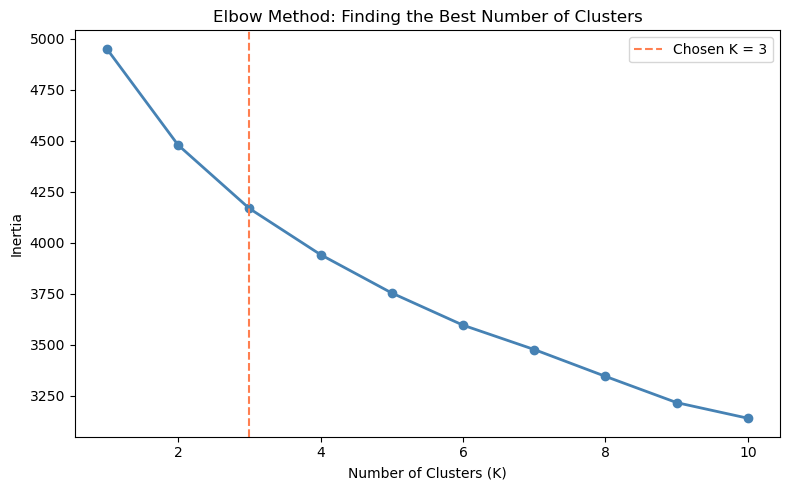

In [103]:
# Plotting the Elbow Method chart to visualize the inertia drop across K values
plt.figure(figsize=(8, 5))

# Drawing the inertia line with markers at each K value
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)

# Adding a vertical line at K=3 to show the chosen value
plt.axvline(x=3, color='coral', linestyle='--', label='Chosen K = 3')

# Adding title and axis labels
plt.title("Elbow Method: Finding the Best Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.legend()
plt.tight_layout()
plt.show()

#### Why I chose K = 3

Looking at the elbow chart, the inertia drops most noticeably between K=1 and K=3. After K=3 the reductions become smaller and more gradual, meaning that adding more clusters does not give a proportional improvement in how well the model separates the data. Three clusters also produce results that make clear business sense for ReturnWise. The three groups that emerge are orders that were fully returned, orders from loyal frequent buyers with almost no returns, and orders from occasional safe buyers. These three segments are easy to understand, distinct from each other, and directly actionable for a marketing and operations team.

#### Step 2: Training the final K-means model

In [104]:
# Creating the final K-means model with 3 clusters
# Setting random_state to 42 for reproducibility
# Setting n_init to 10 so the model runs 10 times with different starting points and picks the best result
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Training the model and getting the cluster label for each order
cluster_labels = kmeans.fit_predict(X_scaled)

# Displaying the first 10 cluster labels
print("Sample Cluster Labels (first 10):")
print(cluster_labels[:10])

Sample Cluster Labels (first 10):
[0 2 2 2 0 0 1 1 0 2]


In [105]:
# Counting how many orders are in each cluster
print("Number of Orders in Each Cluster:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Number of Orders in Each Cluster:
0    131
1    116
2    203
Name: count, dtype: int64


#### Step 3: Adding cluster labels back to the dataset

In [106]:
# Creating a copy of the cleaned dataset to add cluster labels to
df_clustered = df_clean.copy()

# Adding the cluster label as a new column
df_clustered['Cluster'] = cluster_labels

# Displaying the first five rows with the cluster column added
df_clustered[['Order_ID', 'Customer_Age', 'Product_Price', 'Prior_Return_Count', 'Returned', 'Cluster']].head()

,Order_ID,Customer_Age,Product_Price,Prior_Return_Count,Returned,Cluster
0,ORD-10116,43,388.21,0,1,0
1,ORD-10179,30,65.04,0,0,2
2,ORD-10088,41,112.13,0,0,2
3,ORD-10411,38,143.35,0,0,2
4,ORD-10005,40,22.62,0,1,0


---

#### Task 4: Analyzing and Interpreting the Clusters

In [107]:
# Calculating the average value of each numerical feature for each cluster
cluster_summary = df_clustered.groupby('Cluster')[numerical_columns].mean().round(2)

# Adding the count of orders in each cluster
cluster_summary['Order_Count'] = df_clustered['Cluster'].value_counts().sort_index()

# Displaying the full cluster summary table
print("Cluster Summary Table:")
cluster_summary

Cluster Summary Table:


,Customer_Age,Product_Price,Discount_Percent,Delivery_Time_Days,Items_In_Order,Previous_Orders,Prior_Return_Count,Product_Rating,Product_Page_Views,Return_Window_Days,Returned,Order_Count
Cluster,,,,,,,,,,,,
0,38.22,207.59,14.16,3.89,2.27,6.17,0.92,3.80,4.83,37.66,1.00,131
1,35.06,210.08,10.04,3.53,2.85,15.32,1.72,4.00,5.34,30.41,0.03,116
2,40.20,218.33,10.74,3.41,2.06,3.65,0.51,4.01,4.25,40.97,0.00,203


In [108]:
# Naming each cluster based on its characteristics from the summary table
segment_names = {
    0: 'High Return Risk Orders',
    1: 'Loyal Frequent Buyers',
    2: 'Occasional Safe Buyers'
}

# Adding the segment name as a new column in the clustered dataset
df_clustered['Segment_Name'] = df_clustered['Cluster'].map(segment_names)

# Displaying the count of orders in each named segment
print("Orders per Segment:")
print(df_clustered['Segment_Name'].value_counts())

Orders per Segment:
Segment_Name
Occasional Safe Buyers     203
High Return Risk Orders    131
Loyal Frequent Buyers      116
Name: count, dtype: int64


In [109]:
# Setting pandas display options so the full text is visible in each cell
pd.set_option('display.max_colwidth', None)

# Creating a business-friendly interpretation table for each segment
segment_interpretation = pd.DataFrame({
    'Segment': ['High Return Risk Orders', 'Loyal Frequent Buyers', 'Occasional Safe Buyers'],
    'Order Count': [131, 116, 203],
    'Key Characteristics': [
        'All orders returned. Highest discount at 14 percent. Moderate delivery time. Lowest product rating at 3.80.',
        '3 percent return rate. Average of 15 previous orders. Higher prior return count from past activity. Active buying history.',
        'Zero returns. Fewest previous orders at 3.6. Lowest prior return count. Longest return window at 41 days.'
    ],
    'Business Meaning': [
        'Orders driven by heavy discounts that may not match customer expectations or product fit.',
        'Established customers who buy often and rarely return despite a longer purchase history.',
        'Newer or occasional customers with careful buying habits and no return history.'
    ]
})

print("Segment Interpretation:")
segment_interpretation.style.set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

Segment Interpretation:


,Segment,Order Count,Key Characteristics,Business Meaning
0,High Return Risk Orders,131,All orders returned. Highest discount at 14 percent. Moderate delivery time. Lowest product rating at 3.80.,Orders driven by heavy discounts that may not match customer expectations or product fit.
1,Loyal Frequent Buyers,116,3 percent return rate. Average of 15 previous orders. Higher prior return count from past activity. Active buying history.,Established customers who buy often and rarely return despite a longer purchase history.
2,Occasional Safe Buyers,203,Zero returns. Fewest previous orders at 3.6. Lowest prior return count. Longest return window at 41 days.,Newer or occasional customers with careful buying habits and no return history.


#### How many segments were found?

I found 3 customer and order segments in this dataset. Cluster 0 contains 131 orders and all of them were returned. Cluster 1 contains 116 orders from loyal frequent buyers who rarely return. Cluster 2 is the largest group with 203 orders from occasional safe buyers with no returns.

#### What are the main characteristics of each segment?

The High Return Risk segment is defined by the fact that every single order in this group was returned. These orders also received the highest average discount at 14 percent and had a slightly lower average product rating of 3.80. This pattern suggests that heavy discounts may be attracting purchases that do not align with customer expectations.

The Loyal Frequent Buyers segment has the highest number of previous orders at 15 on average, meaning these are established long-term customers. Despite having the highest prior return count at 1.72, their current return rate is only 3 percent, which suggests they have learned what works for them and are buying more confidently.

The Occasional Safe Buyers segment is the largest group and has zero returns. These customers have the fewest previous orders at 3.6 on average and the longest return window at 41 days, yet they chose not to return anything. This group may represent more careful buyers who research before purchasing.

#### How are the segments different from each other?

The three segments differ most clearly on three dimensions: return rate, purchase frequency, and discount sensitivity. The High Return Risk group has a 100 percent return rate while the other two have almost none. The Loyal Frequent Buyers group has far more purchase history than the other two, making them the most engaged customer group. The High Return Risk group received the highest discounts, while the other two groups received more moderate discounts. Product rating also separates the groups slightly, with the High Return Risk group showing the lowest average rating at 3.80 compared to around 4.00 for the other two.

#### Which segment may be the most valuable for the business?

The Loyal Frequent Buyers segment is the most valuable. These customers have placed an average of 15 previous orders, which means they bring consistent and repeated revenue to the business. Their return rate is only 3 percent despite having a history of prior returns, which tells me they have developed trust in the brand and confidence in their purchases. Retaining and rewarding this group should be a top priority because they represent long-term revenue with low operational cost from returns.

#### Which segment may need more marketing attention?

The High Return Risk segment needs the most urgent attention. Every order in this group was returned, which represents a significant financial burden for the business in reverse shipping, restocking, and refund processing costs. The connection between high discounts and 100 percent return rates in this group suggests that the business may be attracting purchases through heavy promotions that do not result in satisfied customers. This group needs better product information before purchase, more accurate sizing guides, and possibly a review of whether the discount strategy is attracting the right kind of demand.

---

#### Task 5: Visualizing the Clusters

#### Visualization 1: Elbow Method Plot

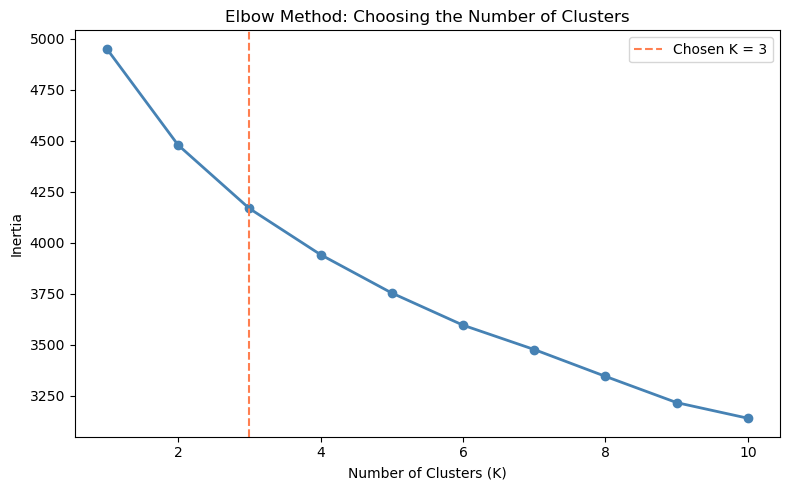

In [110]:
# Plotting the Elbow Method chart to show how inertia decreases as K increases
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='coral', linestyle='--', label='Chosen K = 3')
plt.title("Elbow Method: Choosing the Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.legend()
plt.tight_layout()
plt.show()

#### What the Elbow Method chart shows

The elbow chart shows how the total inertia, which measures how spread out the points are within each cluster, decreases as the number of clusters increases. The steepest drops happen between K=1 and K=3. After K=3 the curve flattens out and each additional cluster gives a smaller improvement. This pattern supports choosing K=3 as the point where adding more clusters stops being meaningfully beneficial.

#### Visualization 2: Scatter Plot of Discount Percent vs Prior Return Count

#### Why I chose these features for the scatter plot

My original choice was to plot Discount_Percent against Prior_Return_Count. However, both of those columns store a very limited range of values. Prior_Return_Count is a whole number between 0 and 5, and Discount_Percent has only a few distinct values in the dataset. When two features like this are plotted against each other, every point snaps to a fixed row and column position and the chart ends up looking like a grid rather than a scatter of individual data points. That kind of chart makes it very difficult to see how the segments are actually distributed.

I switched to Previous_Orders on the horizontal axis and Product_Price on the vertical axis because both of these are continuous features that spread across a much wider range of values. This gives the dots room to spread naturally across the chart and makes it easier to see how the three segments differ from each other visually.

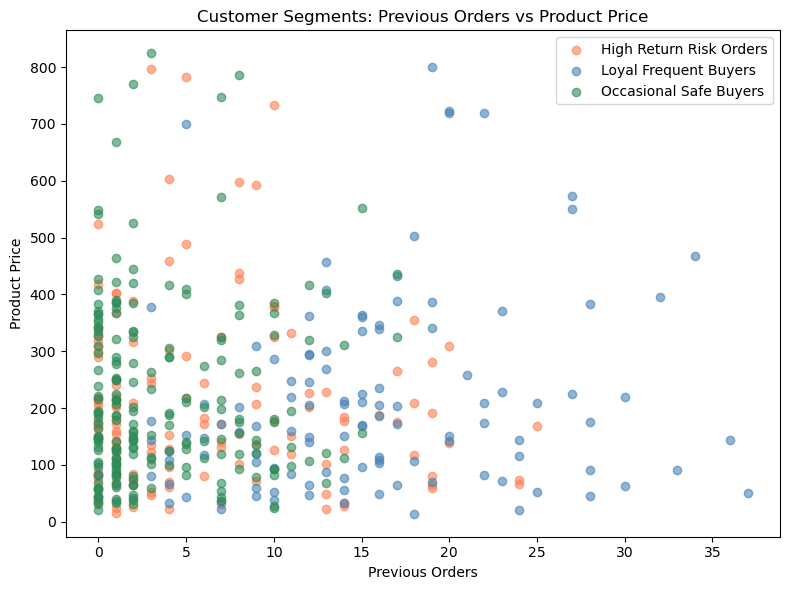

In [111]:
# Creating a scatter plot using two continuous features that clearly separate the segments
plt.figure(figsize=(8, 6))

# Plotting each segment with a different color and label
colors = {'High Return Risk Orders': 'coral', 'Loyal Frequent Buyers': 'steelblue', 'Occasional Safe Buyers': 'seagreen'}

for segment, color in colors.items():
    segment_data = df_clustered[df_clustered['Segment_Name'] == segment]
    plt.scatter(
        segment_data['Previous_Orders'],
        segment_data['Product_Price'],
        label=segment,
        color=color,
        alpha=0.6
    )

# Adding title, axis labels, and legend
plt.title("Customer Segments: Previous Orders vs Product Price")
plt.xlabel("Previous Orders")
plt.ylabel("Product Price")
plt.legend()
plt.tight_layout()
plt.show()

#### What the scatter plot shows

This scatter plot compares the number of previous orders with product price across the three segments. The Loyal Frequent Buyers segment stretches further to the right along the horizontal axis, confirming that these customers have a much longer purchase history than the other two groups. The High Return Risk and Occasional Safe Buyers groups both cluster toward the lower left where previous order counts are lower, but they differ in their return behavior which is reflected in their cluster colors. Switching to these two continuous features avoids the grid pattern that would appear with integer-only columns and gives a clearer visual picture of how the segments spread across the data.

#### Visualization 3: Bar Chart Comparing Cluster Averages

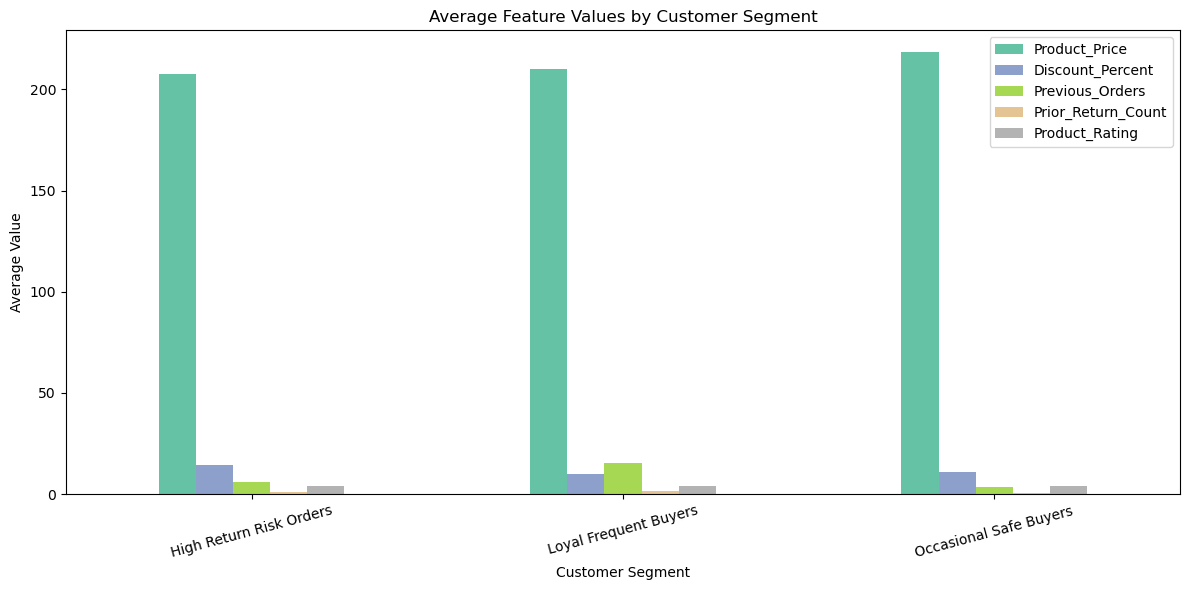

In [112]:
# Selecting key features to compare across segments in a bar chart
compare_features = ['Product_Price', 'Discount_Percent', 'Previous_Orders', 'Prior_Return_Count', 'Product_Rating']

# Calculating the mean of each feature per segment
bar_data = df_clustered.groupby('Segment_Name')[compare_features].mean().round(2)

# Plotting the bar chart
bar_data.plot(kind='bar', figsize=(12, 6), colormap='Set2')

# Adding title and axis labels
plt.title("Average Feature Values by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#### What the bar chart shows

This bar chart compares key feature averages across all three customer segments side by side. It clearly shows that Loyal Frequent Buyers have by far the highest Previous_Orders count, confirming their status as the most engaged group. The High Return Risk segment stands out with the highest Discount_Percent and the lowest Product_Rating. Occasional Safe Buyers are consistently moderate across all features. This comparison gives a clean visual summary of what makes each segment different from the others.

#### Visualization 4: PCA Scatter Plot

In [113]:
# Importing PCA for dimensionality reduction to visualize clusters in 2D
from sklearn.decomposition import PCA

# Creating a PCA model that reduces all features down to 2 components
# PCA does not create clusters, it only helps visualize the clusters K-means already found
pca = PCA(n_components=2)

# Applying PCA to the scaled features
X_pca = pca.fit_transform(X_scaled)

# Adding the two PCA components to the clustered dataset
df_clustered['PCA1'] = X_pca[:, 0]
df_clustered['PCA2'] = X_pca[:, 1]

# Checking how much variance each PCA component explains
explained = pca.explained_variance_ratio_
print("Variance explained by PCA1:", round(explained[0], 4))
print("Variance explained by PCA2:", round(explained[1], 4))
print("Total variance explained :", round(explained.sum(), 4))

Variance explained by PCA1: 0.1198
Variance explained by PCA2: 0.1167
Total variance explained : 0.2365


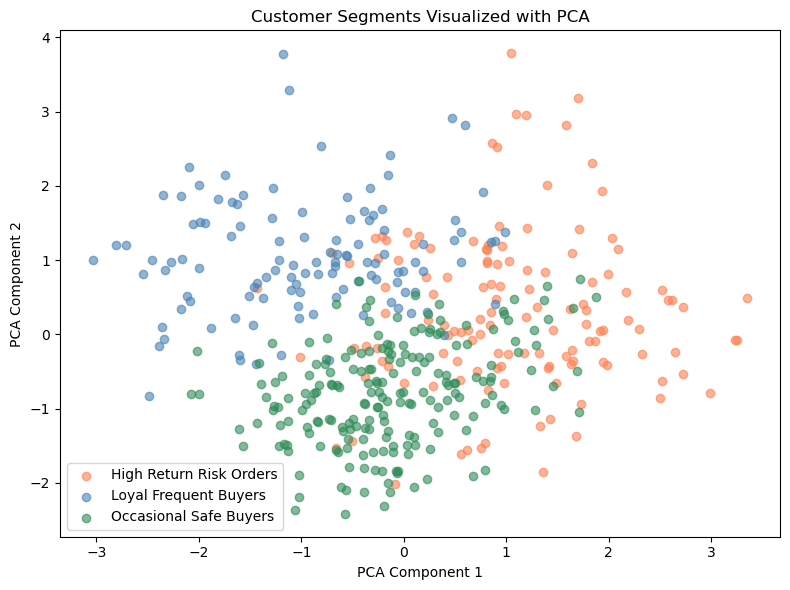

In [114]:
# Plotting the PCA visualization with each segment shown in a different color
plt.figure(figsize=(8, 6))

for segment, color in colors.items():
    segment_data = df_clustered[df_clustered['Segment_Name'] == segment]
    plt.scatter(
        segment_data['PCA1'],
        segment_data['PCA2'],
        label=segment,
        color=color,
        alpha=0.6
    )

# Adding title, axis labels, and legend
plt.title("Customer Segments Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

#### What the PCA chart shows

PCA reduces all 11 features into two components so the clusters can be visualized in a 2D chart. The High Return Risk segment forms a distinct band that is clearly separated from the other two groups along the horizontal axis. The Loyal Frequent Buyers and Occasional Safe Buyers overlap somewhat in the middle of the chart, which makes sense given that both groups have very low return rates. Their separation is driven more by purchase frequency than by return behavior. The PCA chart confirms that the three segments are genuinely distinct in the data and not just randomly assigned groups.

---

#### Task 6: Business Interpretation

In [115]:
# Ensuring full text is visible in the output table
pd.set_option('display.max_colwidth', None)

# Creating a business strategy table to summarize recommended actions for each segment
business_strategy = pd.DataFrame({
    'Segment': ['High Return Risk Orders', 'Loyal Frequent Buyers', 'Occasional Safe Buyers'],
    'Pattern Discovered': [
        '100% return rate, high discounts, lower product ratings',
        '3% return rate, 15 previous orders, established buying history',
        '0% return rate, fewer previous orders, cautious buying behavior'
    ],
    'Recommended Marketing Strategy': [
        'Improve product descriptions and sizing guides before purchase. Review discount strategy to attract better-fit customers.',
        'Reward loyalty through personalized offers, early access to new products, and retention campaigns.',
        'Nurture with informative content, first-time buyer incentives, and reliable delivery promises to build trust.'
    ]
})

print("Business Strategy by Segment:")
business_strategy.style.set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

Business Strategy by Segment:


,Segment,Pattern Discovered,Recommended Marketing Strategy
0,High Return Risk Orders,"100% return rate, high discounts, lower product ratings",Improve product descriptions and sizing guides before purchase. Review discount strategy to attract better-fit customers.
1,Loyal Frequent Buyers,"3% return rate, 15 previous orders, established buying history","Reward loyalty through personalized offers, early access to new products, and retention campaigns."
2,Occasional Safe Buyers,"0% return rate, fewer previous orders, cautious buying behavior","Nurture with informative content, first-time buyer incentives, and reliable delivery promises to build trust."


#### What patterns did I discover?

The clustering revealed three clearly different order profiles. The most striking pattern is that orders with the highest discount levels and lower product ratings cluster together and all end up being returned. This tells me that discount-driven purchases are creating a return problem. The second pattern is that customers with a long purchase history show very low current return rates, even though they have more prior returns overall. This suggests that experience with the brand builds purchasing confidence. The third pattern is that a large group of customers with little purchase history are making safe, return-free purchases, possibly because they are researching carefully before buying.

#### How can the business use these segments?

The business can use these segments in several practical ways. For the High Return Risk segment, the priority is prevention. The company can identify orders at checkout that match the profile of this segment and trigger automated product guidance emails, better size recommendation tools, or proactive customer support. For Loyal Frequent Buyers, the focus should be on retention and cross-selling since these customers already trust the brand and generate consistent revenue. For Occasional Safe Buyers, the opportunity is to convert them into more frequent buyers by showing them that the brand is reliable and worth returning to.

#### What marketing strategy would I suggest for each segment?

For High Return Risk Orders, I would suggest reviewing the discount and promotion strategy to ensure it is attracting customers who genuinely want the product rather than impulse buyers. Investing in better product page quality, clearer size guides, and more accurate product photos would also help reduce expectations mismatches.

For Loyal Frequent Buyers, I would suggest a loyalty program with tier-based rewards, personalized product recommendations based on their purchase history, and early access to sales or new arrivals. These customers are already valuable and keeping them engaged is more cost-effective than acquiring new ones.

For Occasional Safe Buyers, I would suggest an educational content strategy that helps them discover more products they are likely to enjoy. Sending curated recommendations based on their previous safe purchases and gentle re-engagement emails after periods of inactivity could help grow this group into more frequent buyers.

#### How can this analysis help the business improve decision-making?

Before this analysis, the business was likely treating all orders the same and reacting to returns after they happened. The segmentation gives the team a way to move from reactive to proactive. Instead of waiting for returns to pile up, the business can now identify which orders fit the high risk profile at the time of purchase and intervene early. It also helps the business prioritize where to invest marketing resources. Rather than spreading budget equally, the team can direct retention efforts toward loyal buyers and prevention efforts toward high risk orders where the return cost is already predictable.

---

#### Task 7: Limitations and Responsible AI Reflection

In [116]:
# Creating a responsible AI reflection table following the professor's style
responsible_ai = pd.DataFrame({
    'Responsible AI Issue': [
        'Dataset Limitation',
        'K-means Limitations',
        'Risk of Bias',
        'Human Judgment'
    ],
    'Reflection': [
        'The dataset is synthetic and may not reflect real customer behavior accurately. Missing values in Region, Product_Price, and Product_Rating were filled with median or mode values, which may have introduced some noise into the clustering.',
        'K-means requires the user to choose K in advance, which is not always straightforward. It also assumes that clusters are roughly spherical and equal in size, which is not always true in real customer data. The model is also sensitive to outliers.',
        'If the business uses these clusters to restrict services or apply stricter policies to the High Return Risk segment, customers in that group may be treated unfairly. Returns can happen for legitimate reasons like defective products, incorrect sizing information, or misleading product descriptions, none of which are the the customer is not at fault.',
        'Cluster labels are mathematical groupings and do not capture the full story behind each order. A manager reviewing flagged orders needs to consider individual context, apply fair judgment, and avoid using segment labels to automatically disadvantage any customer.'
    ]
})

print("Responsible AI Reflection:")
responsible_ai.style.set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

Responsible AI Reflection:


,Responsible AI Issue,Reflection
0,Dataset Limitation,"The dataset is synthetic and may not reflect real customer behavior accurately. Missing values in Region, Product_Price, and Product_Rating were filled with median or mode values, which may have introduced some noise into the clustering."
1,K-means Limitations,"K-means requires the user to choose K in advance, which is not always straightforward. It also assumes that clusters are roughly spherical and equal in size, which is not always true in real customer data. The model is also sensitive to outliers."
2,Risk of Bias,"If the business uses these clusters to restrict services or apply stricter policies to the High Return Risk segment, customers in that group may be treated unfairly. Returns can happen for legitimate reasons like defective products, incorrect sizing information, or misleading product descriptions, none of which are the the customer is not at fault."
3,Human Judgment,"Cluster labels are mathematical groupings and do not capture the full story behind each order. A manager reviewing flagged orders needs to consider individual context, apply fair judgment, and avoid using segment labels to automatically disadvantage any customer."


#### What is one limitation of the dataset or clustering model?

One important limitation is that this dataset is synthetic, meaning it was created artificially for educational purposes rather than collected from a real retail operation. Because of this, the patterns in the data may be cleaner and more consistent than real customer behavior would be. In a real dataset, customer segments would likely overlap more, contain more noise, and be influenced by external factors like seasonal shopping behavior, economic conditions, or changes in product offerings that this dataset does not capture.

#### Why does K-means not always produce perfect customer segments?

K-means has several built-in limitations that affect how well it can capture real customer groups. First, it requires the user to choose the number of clusters K before running the model, and that choice is based on judgment rather than a definitive right answer. Second, K-means assumes that clusters are roughly spherical and similar in size, but real customer groups rarely fit that shape perfectly. Third, the algorithm is sensitive to outliers because extreme values pull the cluster centers toward them. Fourth, K-means will always find K groups even if the natural structure of the data does not support that many distinct segments. The results need to be evaluated by a person who understands the business context, not accepted at face value.

#### What kind of bias or unfair decision could happen without human review?

If the business uses cluster labels to automatically apply stricter policies to customers in the High Return Risk segment, it could end up unfairly penalizing customers whose returns were caused by factors outside their control. A customer who returned a product because it arrived damaged, did not match the product description, or had a sizing error in the company's own guide should not be treated the same as someone who is exploiting the return policy. Applying automated restrictions based purely on a cluster label could create a negative experience for customers who have a legitimate complaint, damage brand trust, and potentially create legal or ethical concerns depending on the nature of the restrictions.

#### Why should human judgment still be used when making marketing decisions?

Clustering is a pattern discovery tool, not a decision-making tool. It tells me what groups exist in the data based on numbers, but it cannot tell me why a customer is in a particular group, what their individual circumstances are, or what the right action is for them specifically. A marketing manager reviewing a high-risk order needs to consider whether the product itself has known issues, whether the customer has a complaint open, whether the return window is almost expired, and whether the customer has expressed dissatisfaction. None of that context lives in the cluster label.

Using model results without human review also creates a risk that historical patterns, which may reflect past business mistakes rather than customer behavior, become encoded into future decisions. If a certain product category had poor descriptions in the past and generated many returns as a result, the model will learn that category is risky. A human reviewer would know to fix the descriptions rather than flag customers from that category as problematic.